In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
sites = ('US-Ne1', 'US-Ne2', 'US-Ne3', 'US-Var', 'US-GLE', 'US-Me2', 'US-NR1', 'US-ARM', 'US-SRG', 'US-Wkg', 'US-WCr', 'US-SRM', 'US-CMW')
for name in sites:
    df = pd.read_csv(name +'_monthly_data.csv', sep = ',')
    openET = pd.read_csv('monthly_data.dat', sep = '\t', header = 1, index_col = 'Site ID')
    sif = pd.read_csv('GOSIF_timeseries_allsites.csv', sep = ',')
    
    df_open = openET.loc[name]
    df_open = df_open.rename(columns = {"DATE" : "Date"})
    df_open["Date"] = pd.to_datetime(df_open["Date"])
    df_open = df_open.set_index("Date")
    
    df_flux = [list(pair) for pair in zip(df.date, df.ET_corr)]
    df_flux = pd.DataFrame(df_flux, columns = ["Date", "observed_ET"])
    df_flux["Date"] = pd.to_datetime(df_flux["Date"])
    df_flux["first_of_month"] = df_flux["Date"].dt.to_period("M").dt.to_timestamp()
    df_flux = df_flux.drop(columns = ['Date'])
    df_flux = df_flux.rename(columns = {"first_of_month" : "Date"})
    df_flux = df_flux.set_index("Date")
    
    df_sif = [list(pair) for pair in zip(sif.Date, sif[name])]
    df_sif = pd.DataFrame(df_sif, columns = ["Date", "SIF"])
    df_sif["Date"] = pd.to_datetime(df_sif["Date"])
    df_sif = df_sif.set_index("Date")
    
    df_data = pd.concat([df_sif, df_flux], join='inner', axis=1)
    df_data = pd.merge(df_data, df_open, how = "left",left_on = "Date", right_on = "Date")

    print(name)
    display(df_data)
    df_data.to_csv(name+".csv")

US-Ne1


,SIF,observed_ET,geeSEBAL,PT-JPL,SSEBop,SIMS,eeMETRIC,DisALEXI,Ensemble
Date,,,,,,,,,
2001-01-01,0.0028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,-0.0068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-01,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-04-01,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-05-01,0.1419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-08-01,0.4775,140.206199,147.8,130.7,131.4,123.0,137.0,132.6,131.0
2019-09-01,0.2637,88.921888,93.7,103.4,78.3,112.0,125.2,76.1,98.1
2019-10-01,0.0668,25.664186,33.6,41.9,40.5,57.0,56.8,38.4,38.6


US-Ne2


,SIF,observed_ET,geeSEBAL,PT-JPL,SSEBop,SIMS,eeMETRIC,DisALEXI,Ensemble
Date,,,,,,,,,
2001-01-01,0.0028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02-01,-0.0068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-03-01,0.0012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-04-01,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-05-01,0.1419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-08-01,0.4775,134.694723,148.0,130.9,131.0,122.9,137.2,133.5,133.2
2019-09-01,0.2637,77.989507,91.6,102.6,71.0,110.7,120.5,69.8,94.4
2019-10-01,0.0668,27.108554,30.3,41.6,34.9,56.7,48.9,32.9,40.9


US-Ne3


...

,SIF,observed_ET,geeSEBAL,PT-JPL,SSEBop,SIMS,eeMETRIC,DisALEXI,Ensemble
Date,,,,,,,,,
2000-03-01,0.0312,10.253665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,0.0472,16.434690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,0.2393,37.090569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-06-01,0.5090,50.483782,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-07-01,0.5247,60.170683,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-12-01,0.0136,1.878586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,0.0137,5.026224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-01,0.0136,10.045890,NaN,NaN,NaN,NaN,NaN,NaN,NaN


US-SRM


,SIF,observed_ET,geeSEBAL,PT-JPL,SSEBop,SIMS,eeMETRIC,DisALEXI,Ensemble
Date,,,,,,,,,
2003-01-01,0.0078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-02-01,0.0081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-03-01,0.0070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-04-01,0.0030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-05-01,0.0028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2020-02-01,0.0112,24.199859,35.1,63.5,20.9,NaN,45.0,40.5,35.4
2020-03-01,0.0211,34.142535,53.0,74.9,30.6,NaN,66.0,56.6,56.2
2020-04-01,0.0304,25.053780,67.4,46.9,21.7,NaN,56.3,54.2,56.2


US-CMW


,SIF,observed_ET,geeSEBAL,PT-JPL,SSEBop,SIMS,eeMETRIC,DisALEXI,Ensemble
Date,,,,,,,,,
2000-03-01,-0.0018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-01,-0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-01,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-06-01,0.0155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-07-01,0.0231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2019-08-01,0.0391,112.688986,168.4,177.2,155.3,NaN,210.7,126.0,177.9
2019-09-01,0.0396,99.744555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-01,0.0285,73.282385,89.2,122.0,111.0,NaN,146.3,80.6,109.8


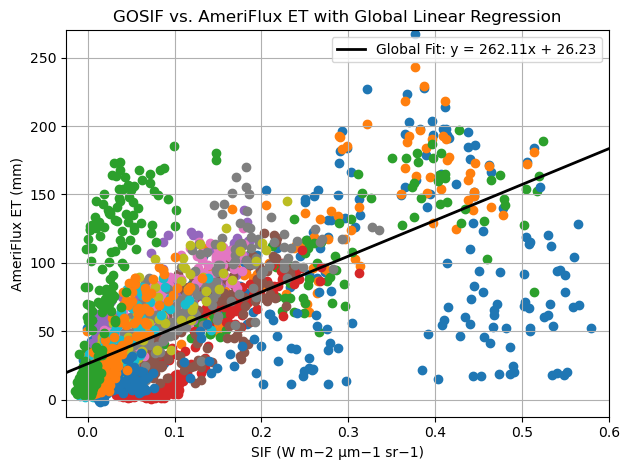

Global Linear Regression: SIF ET = 262.1087 * SIF + 26.2301


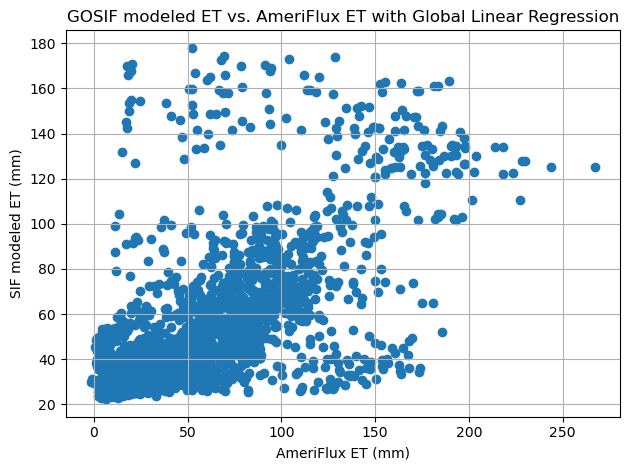

-0.1881651914836482


In [3]:
fn = ('US-Ne1', 'US-Ne2', 'US-Ne3', 'US-Var', 'US-GLE', 'US-Me2', 'US-NR1', 'US-ARM', 'US-SRG', 'US-Wkg', 'US-WCr', 'US-SRM', 'US-CMW')
stats = []
all_X = []
all_y = []

for name in fn:
    df = pd.read_csv(name+".csv", delimiter = ",")
    subset = df[["observed_ET", "SIF"]].dropna()
    X = subset["observed_ET"].values
    y = subset["SIF"].values.reshape(-1, 1)
    model = LinearRegression().fit(y, X)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    all_X.extend(X)
    all_y.extend(y)
    
    stats.append({
        "Site": name,
        "m": slope,
        "b": intercept
    })

    plt.scatter(y,X)


all_X = np.array(all_X).reshape(-1, 1)
all_y = np.array(all_y).reshape(-1, 1)

global_model = LinearRegression().fit(all_y, all_X)
slope = global_model.coef_[0][0]
intercept = global_model.intercept_[0]

x_vals = np.linspace(-0.25, 0.63, 100).reshape(-1, 1)
y_vals = global_model.predict(x_vals)
plt.plot(x_vals, y_vals, color='black', label=f"Global Fit: y = {slope:.2f}x + {intercept:.2f}", linewidth=2)


plt.xlabel("SIF (W m−2 μm−1 sr−1)")
plt.ylabel("AmeriFlux ET (mm)")
plt.ylim([-12.5, 270])
plt.xlim([-0.025, 0.6])
plt.title("GOSIF vs. AmeriFlux ET with Global Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("SIF_model_in.pdf", format = "pdf", bbox_inches="tight")
plt.show()


print(f"Global Linear Regression: SIF ET = {slope:.4f} * SIF + {intercept:.4f}")

stats_df = pd.DataFrame(stats)

sif_model = (all_y)*slope + intercept
plt.scatter(all_X, sif_model)
plt.xlabel("AmeriFlux ET (mm)")
plt.ylabel("SIF modeled ET (mm)")
plt.title("GOSIF modeled ET vs. AmeriFlux ET with Global Linear Regression")
plt.grid(True)
plt.tight_layout()
plt.show()
r2 = r2_score(sif_model, all_X)
model_in = {
    "m" : slope,
    "b": intercept
}
print(r2)

fn = ('US-Ne1', 'US-Ne2', 'US-Ne3', 'US-Var')
for name in fn:
    df = pd.read_csv(name+".csv", delimiter = ",")
    model = model_in
    m = model["m"]
    b = model["b"]
    SIF_ET = ((df["SIF"])*m)+b
    df["SIF_ET"] = SIF_ET
    df.to_csv(name+"_SIF.csv")

In [4]:
fp = ("US-Ne1", "US-Ne2", "US-Ne3", "US-Var")
for name in fp:
    df = pd.read_csv(name + "_SIF.csv", delimiter = ',', parse_dates=["Date"])

    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

    monthly_avg = round(df.groupby(df.index.month)["observed_ET"].mean(), 3)
    df["Climatology"] = df.index.month.map(monthly_avg)
    obs_anom = df.observed_ET - df.Climatology 
    df["obs_anom"] = obs_anom

    ensemble_avg = round(df.groupby(df.index.month)["Ensemble"].mean(), 3)
    df["ens_clim"] = df.index.month.map(ensemble_avg)
    ens_anom = df.Ensemble - df.ens_clim
    df["ens_anom"] = ens_anom

    sif_avg = round(df.groupby(df.index.month)["SIF_ET"].mean(), 3)
    df["SIF_clim"] = df.index.month.map(sif_avg)
    SIF_anom = df.SIF_ET - df.SIF_clim
    df["SIF_anom"] = SIF_anom
    df = df.rename(columns = {"SIF_x" : "SIF"})
    df = df.rename(columns = {"observed_ET_x" : "observed_ET"})
    

    df = pd.DataFrame(df)
    df.to_csv(name+"_clim.csv")